# SSC calibration and $\kappa(c)$ (cells 49–57 of the original notebook)

SSC clip ratios on real snapshots, the rank-normalized energy $\kappa(c)$
across r=64 and r=256 runs, and MISR↔SVD agreement.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
if '/mnt/home/nghosh/lora' not in sys.path:
    sys.path.insert(0, '/mnt/home/nghosh/lora')

import json
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

from lora_playground.snapshot_analysis import (
    # snapshot registry + cached loader
    SNAP_ROOT, SNAP_ROOTS, STEPS, STEPS_BY_ROOT,
    RUNS, RUN_A, RUN_B, RUN_C, RUN_D,
    load_snapshot, clear_snapshot_cache,
    # adam-moment / spectrum helpers
    Mtilde, normalized_sigmas, normalized_sigmas_x, stable_rank,
    EPS, BETA1, BETA2,
    # whitening
    spd_half_inv, whitened_NS_input, DELTA_ABS,
    # SSC / polar shape
    _prerescale_unit_op, _polar_uvt, _ssc_svd, _ssc_misr_batched,
    # diagnostic NS iteration (trajectory-returning)
    newton_schulz_polar, polar_express,
)

DEV = SSC_DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {DEV}')
print(f'active RUNS: {RUNS}')
print(f'default STEPS: {STEPS}')


device: cuda
active RUNS: [('3e-2', 64, 5, 'chord-tight'), ('1e-1', 64, 5, 'chord-tight'), ('1e-3', 256, 10, 'chord-tight-clean'), ('1e-1', 256, 10, 'chord-tight-clean')]
default STEPS: [0, 50, 200, 500, 1000, 2000, 4000]


## SSC (Soft Spectral Clipping) calibration on real snapshots

SPECTRA (arXiv:2603.14315) defines $H_c(X) = (I + XX^T/c^2)^{-1/2}\,X$, equivalently $\sigma_i \mapsto \sigma_i/\sqrt{1 + (\sigma_i/c)^2}$. Inside the chord-tight pipeline the polar input is pre-rescaled so $\sigma_{\max}(X_A) = 1$, so $c$ is **dimensionless** and only acts in $[\sigma_{\min}, 1]$. The paper's recommended $c{=}10$ is in their (unrescaled) units; in our normalized setting $h_{10}(1) \approx 0.995$ — essentially identity.

**This cell measures, on real snapshots, which $c$ values actually clip.** If no $c$ in the grid below moves the F-norm ratio meaningfully off $1.0$, the SSC hypothesis is dead and the planned sweep won't run.

For each step and pair, we compute on the §2.5-rescaled whitened input:
- $\|H_c(X_A)\|_{op} / \|X_A\|_{op}$ — operator-norm cap.
- $\|H_c(X_A)\|_F / \|X_A\|_F$ — F-norm reduction (this is what the operator-norm magnitude rule sees through stable-rank).


In [2]:
# ssc_calibration lives in lora_playground.snapshot_analysis.calibration.
import pandas as pd
from lora_playground.snapshot_analysis.calibration import ssc_calibration

print(f'SSC calibration device: {SSC_DEV}')
df_ssc = ssc_calibration()
print(f'rows={len(df_ssc)}, steps={sorted(df_ssc.step.unique())}, c grid={sorted(df_ssc.c.unique())}')
print()
print('=== F-norm ratio  ||H_c(X)||_F / ||X||_F  (median across pairs, step x c) ===')
print(df_ssc.pivot_table(values='f_ratio', index='step', columns='c', aggfunc='median').round(3))
print()
print('=== Op-norm ratio  ||H_c(X)||_op / ||X||_op  (median across pairs, step x c) ===')
print(df_ssc.pivot_table(values='op_ratio', index='step', columns='c', aggfunc='median').round(3))
print()
print('=== F-norm ratio MAX across pairs (lightest clipping) ===')
print(df_ssc.pivot_table(values='f_ratio', index='step', columns='c', aggfunc='max').round(3))
print()
print('=== F-norm ratio MIN across pairs (heaviest clipping) ===')
print(df_ssc.pivot_table(values='f_ratio', index='step', columns='c', aggfunc='min').round(3))
print()
print('=== Stable rank: input X vs H_c(X)  (median, step=2000) ===')
sub = df_ssc[df_ssc.step == 2000]
print(sub.pivot_table(values=['stable_rank_X', 'stable_rank_H'], columns='c', aggfunc='median').round(2))


SSC calibration device: cuda


rows=432, steps=[np.int64(200), np.int64(1000), np.int64(2000), np.int64(4000)], c grid=[np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.5), np.float64(0.7), np.float64(1.0), np.float64(2.0), np.float64(5.0), np.float64(10.0)]

=== F-norm ratio  ||H_c(X)||_F / ||X||_F  (median across pairs, step x c) ===
c      0.1    0.2    0.3    0.5    0.7    1.0    2.0    5.0    10.0
step                                                               
200   0.279  0.465  0.583  0.728  0.811  0.883  0.962  0.993  0.998
1000  0.294  0.463  0.575  0.717  0.796  0.868  0.956  0.992  0.998
2000  0.290  0.455  0.566  0.706  0.787  0.859  0.952  0.991  0.998
4000  0.285  0.439  0.545  0.686  0.774  0.854  0.950  0.991  0.998

=== Op-norm ratio  ||H_c(X)||_op / ||X||_op  (median across pairs, step x c) ===
c     0.1    0.2    0.3    0.5    0.7    1.0    2.0    5.0    10.0
step                                                              
200    0.1  0.196  0.287  0.447  0.573  0.707  0.894  

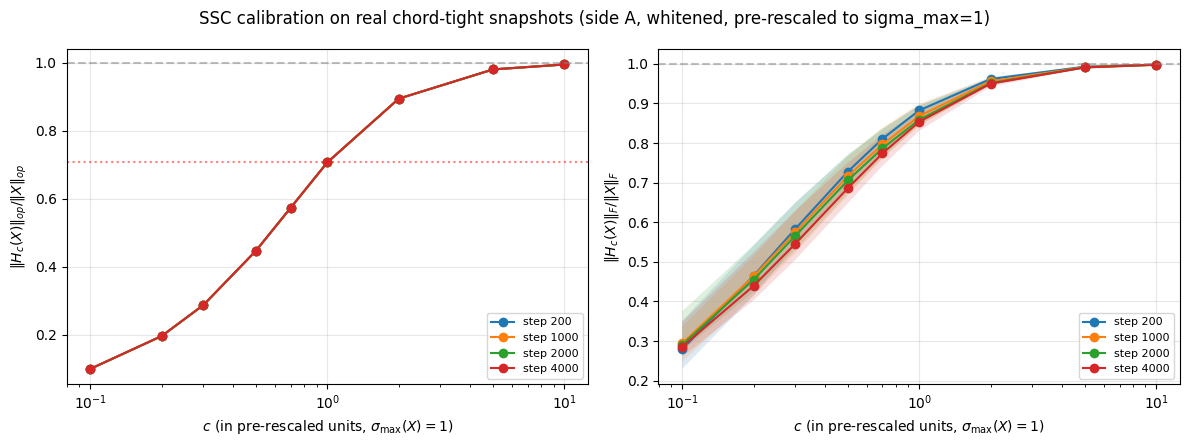

In [3]:
# Plot calibration ratios vs c, overlaid per step.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
for step in sorted(df_ssc.step.unique()):
    sub = df_ssc[df_ssc.step == step].groupby('c').agg({'op_ratio': ['min', 'max', 'median'],
                                                        'f_ratio': ['min', 'max', 'median']})
    cs = sub.index.values
    axes[0].plot(cs, sub[('op_ratio', 'median')], marker='o', label=f'step {step}')
    axes[0].fill_between(cs, sub[('op_ratio', 'min')], sub[('op_ratio', 'max')], alpha=0.15)
    axes[1].plot(cs, sub[('f_ratio', 'median')], marker='o', label=f'step {step}')
    axes[1].fill_between(cs, sub[('f_ratio', 'min')], sub[('f_ratio', 'max')], alpha=0.15)
for ax, ylab in zip(axes, [r'$\|H_c(X)\|_{op} / \|X\|_{op}$',
                            r'$\|H_c(X)\|_F / \|X\|_F$']):
    ax.set_xscale('log')
    ax.set_xlabel(r'$c$ (in pre-rescaled units, $\sigma_{\max}(X) = 1$)')
    ax.set_ylabel(ylab)
    ax.axhline(1.0, ls='--', color='gray', alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
axes[0].axhline(1/np.sqrt(2), ls=':', color='red', alpha=0.5)
fig.suptitle('SSC calibration on real chord-tight snapshots (side A, whitened, pre-rescaled to sigma_max=1)')
fig.tight_layout()
plt.show()


### $\kappa(c)$: rank-normalized spectral energy of the SSC output

For the smooth saturating shape family $h_c(s) = s/\sqrt{1 + (s/c)^2}$, with input
pre-rescaled to $\sigma_{\max}(X) = 1$, define

$$\kappa(c) \;=\; \frac{1}{r}\,\frac{\|H_c(X)\|_F^2}{\|H_c(X)\|_{\mathrm{op}}^2}
\;=\; \frac{\mathrm{stable\_rank}(H_c(X))}{r}.$$

Interpretation: fraction of the rank-normalized spectral energy used by the update.
$\kappa \to 1/r$ is rank-one (input passthrough on a heavy-tailed spectrum);
$\kappa \to 1$ is polar (uniform spectrum). The hypothesis we want to test on real
snapshots: holding $\kappa$ fixed, the required $c$ shrinks with $r$, but the *update
shape* is rank-invariant.


rows=1920
runs: [{'lr': '3e-2', 'lora_r': 64}, {'lr': '1e-1', 'lora_r': 64}, {'lr': '1e-3', 'lora_r': 256}, {'lr': '1e-1', 'lora_r': 256}]

=== kappa(c)  median across pairs+steps, per run ===
c            0.05   0.10   0.20   0.30   0.50   0.70   1.00   2.00   5.00   \
lora_r lr                                                                    
64     1e-1  0.757  0.543  0.327  0.224  0.136  0.103  0.081  0.061  0.055   
       3e-2  0.851  0.650  0.402  0.285  0.182  0.136  0.107  0.082  0.074   
256    1e-1  0.806  0.571  0.320  0.212  0.122  0.088  0.065  0.045  0.039   
       1e-3  0.768  0.523  0.285  0.185  0.106  0.076  0.058  0.042  0.036   

c            10.00  
lora_r lr           
64     1e-1  0.055  
       3e-2  0.073  
256    1e-1  0.038  
       1e-3  0.035  

=== kappa(input) (no SSC) median per run ===
lora_r  lr  
64      1e-1    0.054
        3e-2    0.072
256     1e-1    0.038
        1e-3    0.035
Name: kappa_input, dtype: float64

=== kappa(c) median, sliced by

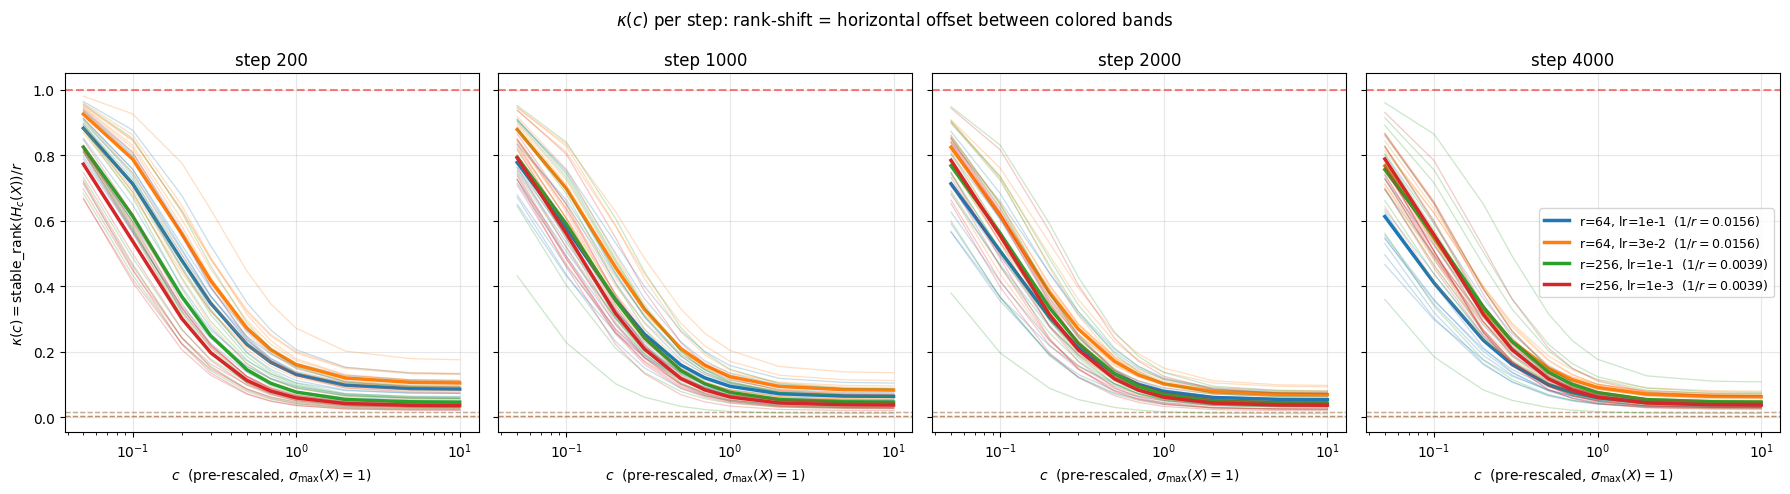

In [4]:
# kappa_calibration lives in lora_playground.snapshot_analysis.calibration.
import pandas as pd
from lora_playground.snapshot_analysis.calibration import kappa_calibration
df_kappa = kappa_calibration()
print(f'rows={len(df_kappa)}')
print('runs:', df_kappa[['lr','lora_r']].drop_duplicates().to_dict('records'))

print()
print('=== kappa(c)  median across pairs+steps, per run ===')
piv = df_kappa.pivot_table(values='kappa',
                           index=['lora_r','lr'], columns='c', aggfunc='median').round(3)
print(piv)

print()
print('=== kappa(input) (no SSC) median per run ===')
print(df_kappa.groupby(['lora_r','lr'])['kappa_input'].median().round(3))

print()
print('=== kappa(c) median, sliced by step (lora_r, lr, step) x c ===')
piv2 = df_kappa.pivot_table(values='kappa',
                            index=['lora_r','lr','step'], columns='c',
                            aggfunc='median').round(3)
print(piv2)

# --- Overlay: kappa(c) per run, one panel per step. ----------------------
# Color = run (r, lr). Faint = individual pairs (no aggregation).
# Bold = mean-over-pairs as a visual anchor. Rank-shift in c shows as a
# horizontal offset between colored bands within each panel; step-drift shows
# as a change between panels.
steps_plot = sorted(df_kappa['step'].unique())
runs_present = sorted(df_kappa[['lora_r','lr']].drop_duplicates()
                      .itertuples(index=False, name=None))
run_colors = {rk: f'C{i}' for i, rk in enumerate(runs_present)}

fig, axes = plt.subplots(1, len(steps_plot),
                         figsize=(4.5 * len(steps_plot), 5.0),
                         sharey=True, squeeze=False)
axes = axes[0]
for ax, step in zip(axes, steps_plot):
    df_step = df_kappa[df_kappa['step'] == step]
    for (r_val, lr_val) in runs_present:
        color = run_colors[(r_val, lr_val)]
        sub_run = df_step[(df_step.lora_r == r_val) & (df_step.lr == lr_val)]
        if sub_run.empty:
            continue
        for pi, g in sub_run.groupby('pair'):
            g = g.sort_values('c')
            ax.plot(g['c'].values, g['kappa'].values,
                    color=color, alpha=0.25, lw=0.9)
        mean_curve = sub_run.groupby('c')['kappa'].mean().sort_index()
        ax.plot(mean_curve.index.values, mean_curve.values,
                color=color, lw=2.5,
                label=fr'r={r_val}, lr={lr_val}  ($1/r={1.0/r_val:.4f}$)')
        ax.axhline(1.0 / r_val, ls='--', color=color, alpha=0.4, lw=1.0)
    ax.axhline(1.0, ls='--', color='red', alpha=0.5)
    ax.set_xscale('log')
    ax.set_xlabel(r'$c$  (pre-rescaled, $\sigma_{\max}(X)=1$)')
    ax.set_title(f'step {step}')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel(r'$\kappa(c) = \mathrm{stable\_rank}(H_c(X)) / r$')
axes[-1].legend(fontsize=9, loc='best')
fig.suptitle(r'$\kappa(c)$ per step: rank-shift = horizontal offset between colored bands')
fig.tight_layout()
plt.show()


### Cell B — singular-value mechanism check

Side-by-side spectrum overlay of $X$, $H_c(X)$, and exact polar$(X)$ (SVD $U V^T$, all $\sigma=1$). The point: SSC caps the top while preserving the tail, vs. polar which inflates every $\sigma$ toward 1. This visually distinguishes SSC ("rank-preserving") from htmuon_p / $\sigma^p$ ("rank-inflating").


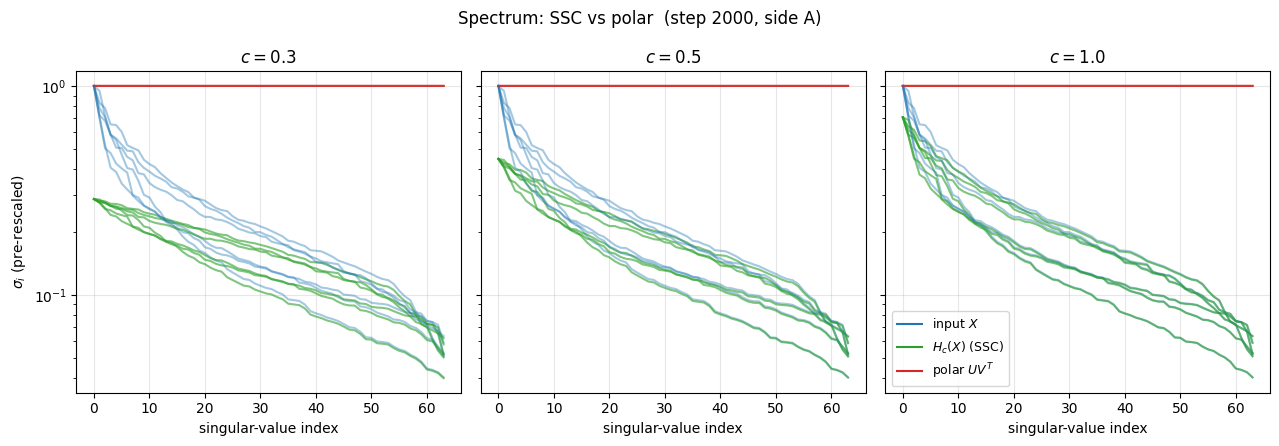

In [5]:
# _polar_uvt lives in lora_playground.snapshot_analysis.ssc.
def plot_ssc_spectrum_overlay(step=2000, cs=(0.3, 0.5, 1.0), n_pairs=6, side='A', device=SSC_DEV):
    snap = load_snapshot(step)
    n_total = len(snap['pair_state'])
    pair_indices = np.linspace(0, n_total - 1, n_pairs, dtype=int)
    fig, axes = plt.subplots(1, len(cs), figsize=(4.3 * len(cs), 4.5), sharey=True)
    for ax, c in zip(axes, cs):
        for pi in pair_indices:
            p = snap['pair_state'][int(pi)]
            X = _prerescale_unit_op(whitened_NS_input(p, side=side).to(device))
            s_X = torch.linalg.svdvals(X).cpu().numpy()
            s_H = torch.linalg.svdvals(_ssc_svd(X, c)).cpu().numpy()
            s_P = torch.linalg.svdvals(_polar_uvt(X)).cpu().numpy()
            ax.plot(s_X, color='C0', alpha=0.4)
            ax.plot(s_H, color='C2', alpha=0.6)
            ax.plot(s_P, color='C3', alpha=0.35)
        ax.set_title(rf'$c = {c}$')
        ax.set_xlabel('singular-value index')
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
    from matplotlib.lines import Line2D
    axes[0].set_ylabel(r'$\sigma_i$ (pre-rescaled)')
    axes[-1].legend([Line2D([],[],color='C0'), Line2D([],[],color='C2'), Line2D([],[],color='C3')],
                    [r'input $X$', r'$H_c(X)$ (SSC)', r'polar $UV^T$'],
                    loc='lower left', fontsize=9)
    fig.suptitle(f'Spectrum: SSC vs polar  (step {step}, side {side})')
    fig.tight_layout()
    return fig

plot_ssc_spectrum_overlay(2000, cs=(0.3, 0.5, 1.0))
plt.show()


### Cell C — MISR ↔ SVD agreement on real snapshots

For each retained $c$, compute SSC via the Newton-Schulz Algorithm 2 (MISR) routine `_ssc_misr_batched` and compare to the SVD reference `_ssc_svd`. Pass criterion: relative F-norm error $< 10^{-3}$ at $K=10$ across all snapshot pairs.


In [6]:
def ssc_misr_vs_svd(steps=(200, 1000, 2000, 4000),
                    cs=(0.3, 0.5, 1.0, 3.0),
                    Ks=(5, 10, 15),
                    n_pairs=12, side='A', device=SSC_DEV):
    rows = []
    for step in steps:
        try:
            snap = load_snapshot(step)
        except FileNotFoundError:
            continue
        n_total = len(snap['pair_state'])
        pair_indices = np.linspace(0, n_total - 1, n_pairs, dtype=int)
        for pi in pair_indices:
            p = snap['pair_state'][int(pi)]
            X = _prerescale_unit_op(whitened_NS_input(p, side=side).to(device))
            for c in cs:
                ref = _ssc_svd(X, c).float()
                ref_norm = ref.norm().item()
                for K in Ks:
                    ns = _ssc_misr_batched(X, c, nsteps=K)
                    err = (ns - ref).norm().item() / max(ref_norm, 1e-30)
                    rows.append({'step': step, 'pair': int(pi), 'c': c, 'K': K, 'rel_err': err})
    return pd.DataFrame(rows)

df_misr = ssc_misr_vs_svd()
print('=== Relative F-norm error  ||MISR - SVD||_F / ||SVD||_F  (MAX over pairs x steps, c x K) ===')
print(df_misr.pivot_table(values='rel_err', index='c', columns='K', aggfunc='max').applymap(lambda x: f'{x:.2e}'))
print()
print('=== Median over pairs x steps ===')
print(df_misr.pivot_table(values='rel_err', index='c', columns='K', aggfunc='median').applymap(lambda x: f'{x:.2e}'))
print()
print('PASS criterion: max rel_err at K=10 < 1e-3 for every c.')
max_at_10 = df_misr[df_misr.K == 10].groupby('c')['rel_err'].max()
print(max_at_10)


=== Relative F-norm error  ||MISR - SVD||_F / ||SVD||_F  (MAX over pairs x steps, c x K) ===
K          5         10        15
c                                
0.3  2.64e-01  8.64e-06  8.65e-06
0.5  2.33e-01  9.30e-06  9.32e-06
1.0  2.22e-01  1.02e-05  1.02e-05
3.0  2.31e-01  1.19e-05  1.19e-05

=== Median over pairs x steps ===
K          5         10        15
c                                
0.3  2.37e-01  7.19e-06  7.21e-06
0.5  2.03e-01  7.72e-06  7.74e-06
1.0  2.01e-01  8.55e-06  8.55e-06
3.0  2.26e-01  9.41e-06  9.41e-06

PASS criterion: max rel_err at K=10 < 1e-3 for every c.
c
0.3    0.000009
0.5    0.000009
1.0    0.000010
3.0    0.000012
Name: rel_err, dtype: float64


/tmp/ipykernel_2131858/3832853893.py:27: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(df_misr.pivot_table(values='rel_err', index='c', columns='K', aggfunc='max').applymap(lambda x: f'{x:.2e}'))
/tmp/ipykernel_2131858/3832853893.py:30: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(df_misr.pivot_table(values='rel_err', index='c', columns='K', aggfunc='median').applymap(lambda x: f'{x:.2e}'))
